# Solution: Challenge Week 04

## Libraries and settings

In [1]:
# Libraries
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Show current working directory
print(os.getcwd())

/workspace/Week_04/challenge


## Import bicycle data

In [2]:
# Read the data
df_orig = pd.read_csv('bicycles.csv', sep=",")

# Show the number of rows and columns
print(df_orig.shape)

# Print the first 10 rows and a selected number of columns
df_orig.iloc[:10,]

(600, 6)


,web-scraper-order,web-scraper-start-url,title_raw,address_raw,price_raw,description_raw
0,1678953522-601,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Velounterstand / Fahrradunterstand für 3-4 Vel...,"Zürich, 8472, 26.02.2023",2'200.-,Velounterstand / Fahrradunterstand für 3-4 Vel...
1,1678953522-602,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Thule FAHRRADTRÄGER Mod. 307130,"Zürich, 8032, 26.02.2023",200.-,"Da wir ohne Velos auf Reise gehen, verkaufen w..."
2,1678953522-603,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Veloständer für 5 Velos,"St. Gallen, 9424, 26.02.2023",15.-,Verankerbarer Veloständer für 5 Fahrräder. Ein...
3,1678953522-604,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Hymer-Veloträger- Multitalent Tele 4,"St. Gallen, 9607, 26.02.2023",320.-,"- Top Zustand, unbenutzt\n- Masse: [LxB(T)xH] ..."
4,1678953522-605,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Veloständer,"Bern, 3472, 26.02.2023",100.-,Veloständer verzinkt für 12 Velos. Länge 4.5m....
5,1678953522-606,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Umwerfer Shimano Deore FD-M610. 3x10. E-Type,"Aargau, 5210, 26.02.2023",10.-,"Termin schriftlich mit mir vereinbaren, erst d..."
6,1678953522-607,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Fahrradträger Veloträger Anhängerkupplung,"Glarus, 8866, 26.02.2023",390.-,"Veloträger für 4 Velos,\nauch für E- Bike auf..."
7,1678953522-608,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Velomechaniker,"Bern, 3612, 26.02.2023",80.-,Ich bin gelernter Velomechaniker und bietet ih...
8,1678953522-609,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Velokorb vorne weiss (Gratis Lieferung),"Zürich, 8004, 26.02.2023",38.-,Gratis Versand innerhalb von ca. 2-4 Arbeitsta...
9,1678953522-610,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Veloträger,"St. Gallen, 9630, 26.02.2023",70.-,Veloträger für AHK für 2 Velos (geht auch für ...


## Show data types

In [3]:
# Show data types
print(df_orig.dtypes)

web-scraper-order        str
web-scraper-start-url    str
title_raw                str
address_raw              str
price_raw                str
description_raw          str
dtype: object


## Count and remove missing values

In [4]:
# Count missing values
print('Count missing values')
print(df_orig.isna().sum())

# Remove missing values
print('\nCheck whether missing values were successfully removed')
df_clean_01 = df_orig.dropna()
df_clean_01.isna().sum()

Count missing values
web-scraper-order        0
web-scraper-start-url    0
title_raw                0
address_raw              0
price_raw                0
description_raw          0
dtype: int64

Check whether missing values were successfully removed


web-scraper-order        0
web-scraper-start-url    0
title_raw                0
address_raw              0
price_raw                0
description_raw          0
dtype: int64

## Count and remove duplicated values

In [5]:
# Count duplicated values
print('Count duplicated values')
print(df_clean_01.duplicated().sum())

# Remove duplicated values
print('\nCheck whether duplicated values were successfully removed')
df = df_clean_01.drop_duplicates()
print(df.duplicated().sum())

Count duplicated values
0

Check whether duplicated values were successfully removed
0


## Create a new variable 'price' with an 'int' as data type

In [6]:
# Extract values using the lambda function
df['price'] = df['price_raw'].apply(lambda x: re.sub('[^\d]', '', x))

# Remove records with no prices
df_sub = df[df['price'] != '']

# Change data type to int
df_sub['price'] = df_sub['price'].astype('int32')

# Check data type
print(df_sub['price'].dtypes)

int32


## Create a subset of the data frame with prices between 200.- and 2000.- CHF

In [7]:
df_sub_02 = df_sub.loc[(df_sub['price'] >= 200) & (df_sub['price'] <= 2000)]
df_sub_02

,web-scraper-order,web-scraper-start-url,title_raw,address_raw,price_raw,description_raw,price
1,1678953522-602,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Thule FAHRRADTRÄGER Mod. 307130,"Zürich, 8032, 26.02.2023",200.-,"Da wir ohne Velos auf Reise gehen, verkaufen w...",200
3,1678953522-604,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Hymer-Veloträger- Multitalent Tele 4,"St. Gallen, 9607, 26.02.2023",320.-,"- Top Zustand, unbenutzt\n- Masse: [LxB(T)xH] ...",320
6,1678953522-607,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Fahrradträger Veloträger Anhängerkupplung,"Glarus, 8866, 26.02.2023",390.-,"Veloträger für 4 Velos,\nauch für E- Bike auf...",390
15,1678953522-616,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,"Veloträger, Fahrradträger 4 , 4er","Schwyz, 8806, 25.02.2023",399.-,"Fahrradträger für 4 Velos\nTraglast ca 65,\nAb...",399
16,1678953522-617,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Fahrradträger 3er Verkauf & Vermietung,"Glarus, 8865, 25.02.2023",355.-,"Für3 Velos\nVerkauf 355,-, Nutzlast 60kg nett...",355
...,...,...,...,...,...,...,...
577,1678953574-1178,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Condor Sarina Damen Velo / City Bike / Red Love,"Aargau, 5600, Heute 07:29",320.-,Zu verkaufen ist dieses wunderbare Condor Sari...,320
578,1678953574-1179,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Alu-Elektro-Faltrad,"Basel-Landschaft, 4410, Heute 07:24",450.-,"2 Stück Campingvelos, elektrisch 3-Gang, aus A...",450
585,1678953574-1186,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Veloträger VW T6/ 6.1,"Luzern, 6122, Heute 06:05",280.-,Wegen nicht Gebrauch zu verkaufen. Der Träger ...,280
593,1678953574-1194,https://www.tutti.ch/de/q/suche/Ak6V2ZWxvc8CUw...,Kindervelo MTB Cycletec Moskito 20 Zoll,"Bern, 3084, Gestern 19:06",200.-,"Das MTB Cycletech Moskito 20? ist ein tolles, ...",200


## Histogramm of bicycle prices

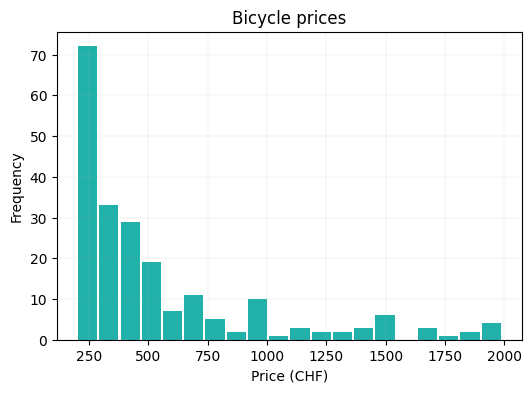

In [8]:
# Histogram
plt.figure(figsize=(6,4))
df_sub_02['price'].plot.hist(grid=True, 
                        bins=20, 
                        rwidth=0.9,
                        color='lightseagreen')
plt.title('Bicycle prices')
plt.xlabel('Price (CHF)')
plt.ylabel('Frequency')
plt.grid(linestyle='-', linewidth=0.1)

##  Save the name of the city / canton from the address string in a new variable

In [9]:
# Extract city / canton (note the split(',') which considering commas)
df_sub_02['location'] = df['address_raw'].str.split(',').str[0]

# Show result
df_sub_02[['address_raw', 'location']]

,address_raw,location
1,"Zürich, 8032, 26.02.2023",Zürich
3,"St. Gallen, 9607, 26.02.2023",St. Gallen
6,"Glarus, 8866, 26.02.2023",Glarus
15,"Schwyz, 8806, 25.02.2023",Schwyz
16,"Glarus, 8865, 25.02.2023",Glarus
...,...,...
577,"Aargau, 5600, Heute 07:29",Aargau
578,"Basel-Landschaft, 4410, Heute 07:24",Basel-Landschaft
585,"Luzern, 6122, Heute 06:05",Luzern
593,"Bern, 3084, Gestern 19:06",Bern


## Create a dictionary with all prices per city / canton

In [10]:
# Use set and dictionary comprehension to create a dictionary
bicycle_dict = {x: df_sub_02.loc[df_sub_02['location'] == x, 'price'].tolist() \
               for x in set(df_sub_02['location'])}

# Print the resulting dictionary keys and values
print('Dictionary with keys and values:')
print(bicycle_dict)

# Print the resulting dictionary keys
print('\nDictionary keys:')
print(bicycle_dict.keys())

# Print the resulting dictionary values
print('\nDictionary values')
print(bicycle_dict.values())

Dictionary with keys and values:
{'Uri': [260], 'Wallis': [200], 'Luzern': [495, 220, 320, 250, 460, 200, 480, 240, 220, 280, 280, 280, 439, 280], 'Schwyz': [399, 250, 324], 'Bern': [449, 1299, 399, 329, 420, 720, 499, 1450, 250, 299, 1480, 249, 499, 200, 479, 400, 499, 329, 399, 250, 399, 225, 299, 299, 269, 1480, 1990, 699, 699, 349, 700, 450, 1490, 1990, 349, 399, 299, 270, 699, 200], 'Tessin': [280], 'Solothurn': [350, 500, 799, 695, 1740, 1950, 690], 'Aargau': [480, 580, 320, 210, 650, 300, 300, 600, 230, 320, 480, 200, 280, 390, 250, 250, 280, 700, 800, 230, 480, 699, 230, 250, 270, 280, 400, 1900, 1700, 250, 320, 500, 300, 499, 1100, 500, 250, 320, 320, 230, 280, 250, 260, 230, 250, 280, 230, 260, 230, 220, 950, 950, 280, 390, 230, 360, 320, 380, 599, 599, 320], 'Basel-Stadt': [1435, 600], 'Basel-Landschaft': [490, 320, 950, 870, 1190, 1440, 555, 450], 'Thurgau': [1900, 400, 400, 200, 450], 'Graubünden': [590, 250, 400], 'St. Gallen': [320, 400, 200, 1460, 210, 1120, 1990, 1120,

## Access elements of the dictionary with all prices in the city of Zürich

In [11]:
# Define the key
mykey = 'Zürich'

# Check whether FERRARI is a key in car_dict
if mykey in bicycle_dict:
    print(f'The key {mykey} exists!')

# Get all values from the key
print(f'\nHere are the available prices of the key {mykey}:')
print(bicycle_dict.get(mykey))

The key Zürich exists!

Here are the available prices of the key Zürich:
[200, 220, 800, 350, 550, 690, 339, 250, 200, 251, 949, 599, 336, 949, 899, 1690, 990, 250, 430, 379, 1290, 990, 240, 550, 990, 230, 270, 200, 950, 790, 1700, 300, 949, 300, 455, 270, 280, 290, 250, 1230, 1030, 375, 450, 800, 240, 220]


### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [12]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1044-azure
Datetime: 2026-03-19 10:28:14
Python Version: 3.11.14
-----------------------------------
